# Task 5: Personal Loan Acceptance Prediction

## Introduction & Problem Statement

Banks run outbound marketing campaigns to cross-sell term deposits and personal loan products. Targeting the right customers improves conversion rates and reduces campaign costs.

**Objective:** Build a classifier to predict which customers are likely to **subscribe / accept** (`y = yes`) a product offer based on their demographics, financial status, and campaign interaction.

**Dataset:** `task5_dataset.csv`  41,188 bank customers (UCI Bank Marketing Dataset, semicolon-separated)

| Feature | Description |
|---|---|
| `age`, `job`, `marital`, `education` | Demographics |
| `default`, `housing`, `loan` | Credit/loan status |
| `contact`, `month`, `day_of_week` | Last contact info |
| `duration` | Last call duration (seconds) |
| `campaign`, `pdays`, `previous`, `poutcome` | Campaign history |
| `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Economic indicators |
| `y` | **Target**   'yes' = accepted, 'no' = declined |

## 1. Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


## 2. Dataset Understanding & Description

In [30]:

df = pd.read_csv('task5_dataset.csv', sep=';')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [31]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [33]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [34]:
# Target distribution
print('Target distribution (y):')
print(df['y'].value_counts())
print(f'\nAcceptance rate: {(df["y"]=="yes").mean()*100:.2f}%')

Target distribution (y):
y
no     36548
yes     4640
Name: count, dtype: int64

Acceptance rate: 11.27%


## 3. Data Cleaning & Preparation

In [35]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

# Count 'unknown' values in categorical columns (encoded as string 'unknown')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('\n"unknown" counts per categorical column:')
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

"unknown" counts per categorical column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


In [36]:
# Replace 'unknown' with NaN, then impute with mode
df.replace('unknown', np.nan, inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values after imputation: {df.isnull().sum().sum()}')

Missing values after imputation: 0


In [37]:
# Encode target: yes=1, no=0
df['y'] = (df['y'] == 'yes').astype(int)

# Label encode all remaining categorical columns
le = LabelEncoder()
remaining_cats = df.select_dtypes(include='object').columns.tolist()
for col in remaining_cats:
    df[col] = le.fit_transform(df[col])

print('All categorical features encoded.')
print(f'Final shape: {df.shape}')
df.head(3)

All categorical features encoded.
Final shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## 4. Exploratory Data Analysis (EDA)

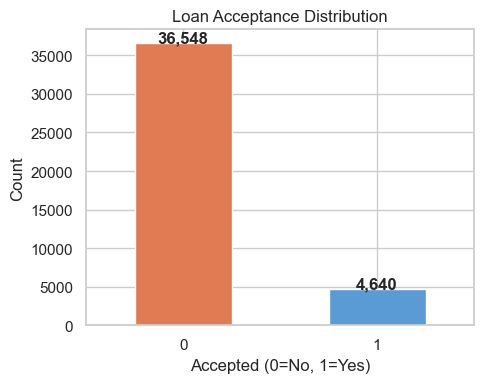

In [38]:
# Target class distribution
plt.figure(figsize=(5, 4))
ax = df['y'].value_counts().sort_index().plot(
    kind='bar', color=['#E07B54', '#5B9BD5'], edgecolor='white', width=0.5
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 200),
                ha='center', fontweight='bold')
plt.title('Loan Acceptance Distribution')
plt.xlabel('Accepted (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

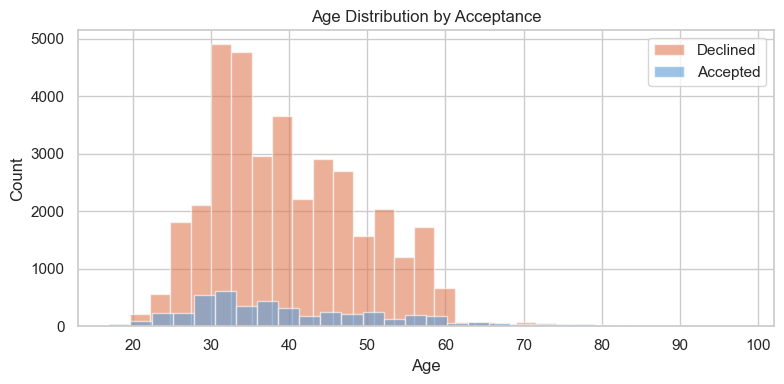

In [39]:
# Age distribution by acceptance
plt.figure(figsize=(8, 4))
for val, label, color in [(0, 'Declined', '#E07B54'), (1, 'Accepted', '#5B9BD5')]:
    plt.hist(df[df['y']==val]['age'], bins=30,
             alpha=0.6, label=label, color=color, edgecolor='white')
plt.title('Age Distribution by Acceptance')
plt.xlabel('Age'); plt.ylabel('Count'); plt.legend()
plt.tight_layout()
plt.show()

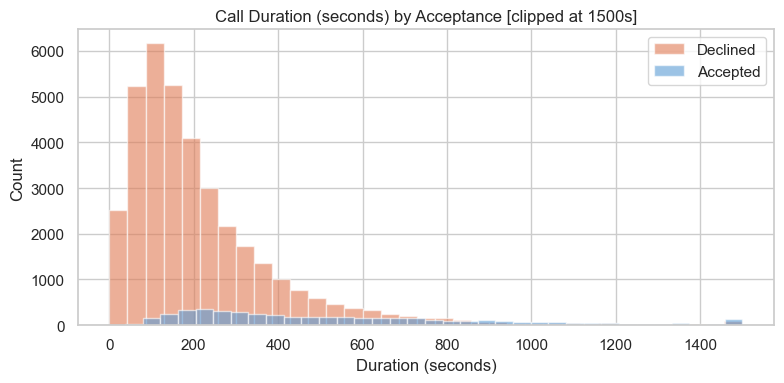

In [40]:
# Call duration histogram by acceptance
plt.figure(figsize=(8, 4))
for val, label, color in [(0, 'Declined', '#E07B54'), (1, 'Accepted', '#5B9BD5')]:
    plt.hist(df[df['y']==val]['duration'].clip(0, 1500), bins=35,
             alpha=0.6, label=label, color=color, edgecolor='white')
plt.title('Call Duration (seconds) by Acceptance [clipped at 1500s]')
plt.xlabel('Duration (seconds)'); plt.ylabel('Count'); plt.legend()
plt.tight_layout()
plt.show()

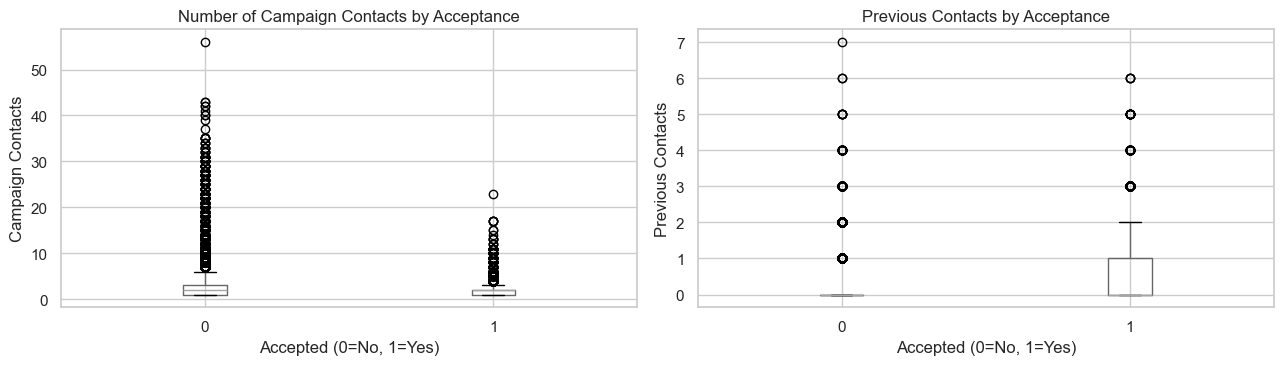

In [41]:
# Box plots: campaign contacts and previous contacts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='campaign', by='y', ax=axes[0])
axes[0].set_title('Number of Campaign Contacts by Acceptance')
axes[0].set_xlabel('Accepted (0=No, 1=Yes)')
axes[0].set_ylabel('Campaign Contacts')

df.boxplot(column='previous', by='y', ax=axes[1])
axes[1].set_title('Previous Contacts by Acceptance')
axes[1].set_xlabel('Accepted (0=No, 1=Yes)')
axes[1].set_ylabel('Previous Contacts')

plt.suptitle('')
plt.tight_layout()
plt.show()

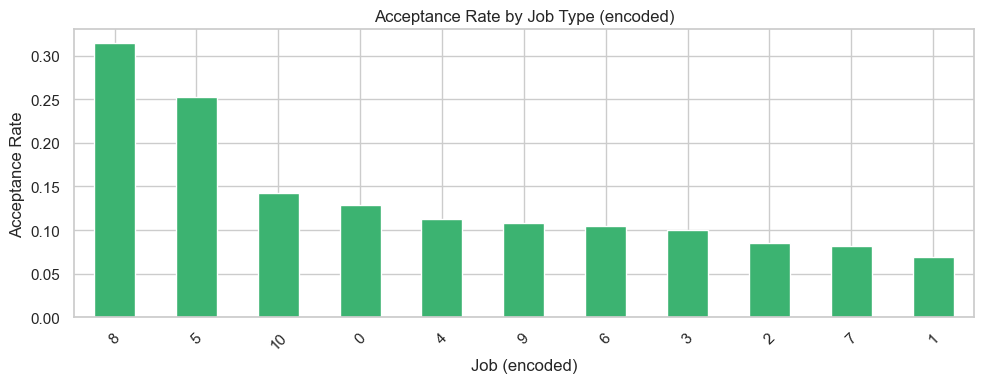

In [42]:
# Acceptance rate by job type (top 10)
job_acceptance = df.groupby('job')['y'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
job_acceptance.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Acceptance Rate by Job Type (encoded)')
plt.xlabel('Job (encoded)')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

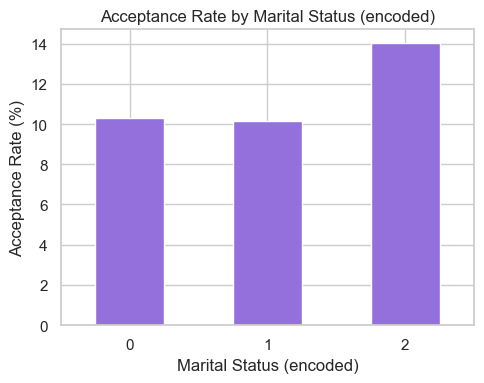

In [43]:
# Acceptance rate by marital status
plt.figure(figsize=(5, 4))
marital_rate = df.groupby('marital')['y'].mean() * 100
marital_rate.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Acceptance Rate by Marital Status (encoded)')
plt.xlabel('Marital Status (encoded)')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

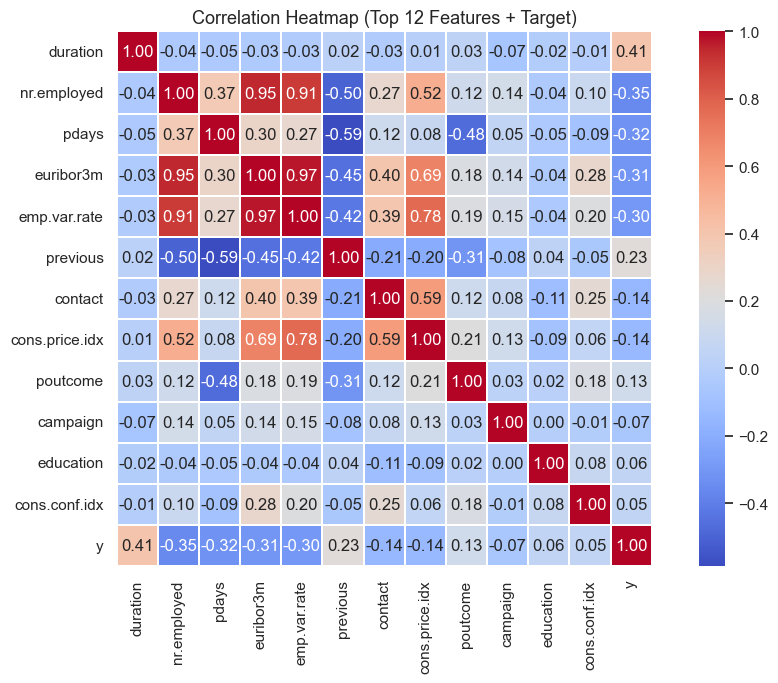

In [44]:
# Correlation heatmap — top 12 features with target
corr_with_target = df.corr()['y'].drop('y').abs().sort_values(ascending=False)
top_features = corr_with_target.head(12).index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[top_features + ['y']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.3, square=True
)
plt.title('Correlation Heatmap (Top 12 Features + Target)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model Training & Testing

In [45]:
X = df.drop(columns=['y'])
y = df['y']

# Standardise features for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X_train.shape[1]}')

Train: 32,950 | Test: 8,238 | Features: 20


In [46]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Both models trained!')

Both models trained!


## 6. Evaluation Metrics

In [47]:
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Decision Tree',       y_pred_dt, y_prob_dt)
]:
    print(f'--- {name} ---')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n')

--- Logistic Regression ---
  Accuracy : 0.9143
  ROC-AUC  : 0.9369

--- Decision Tree ---
  Accuracy : 0.9176
  ROC-AUC  : 0.9355



In [48]:
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Declined', 'Accepted']))
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Declined', 'Accepted']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Declined       0.93      0.98      0.95      7310
    Accepted       0.71      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.82      0.69      0.74      8238
weighted avg       0.90      0.91      0.90      8238

=== Decision Tree ===
              precision    recall  f1-score   support

    Declined       0.94      0.97      0.95      7310
    Accepted       0.68      0.52      0.58       928

    accuracy                           0.92      8238
   macro avg       0.81      0.74      0.77      8238
weighted avg       0.91      0.92      0.91      8238



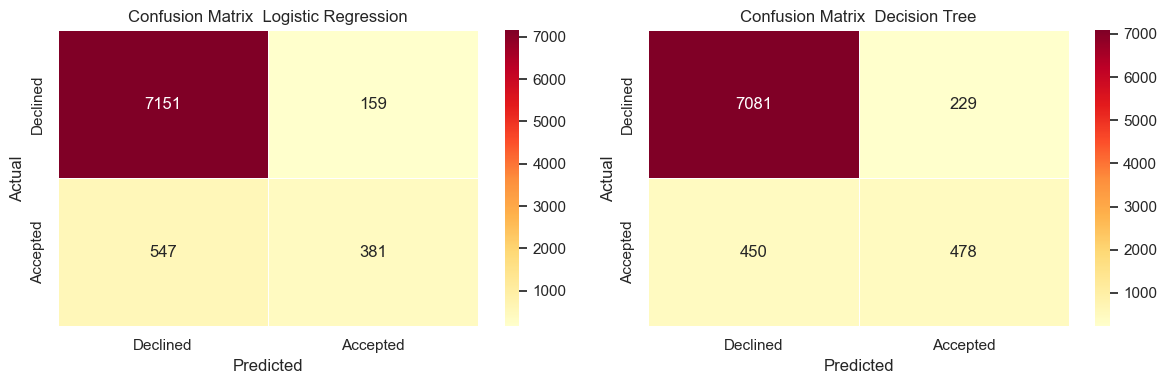

In [49]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(
    axes, [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']
):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap='YlOrRd',
                xticklabels=['Declined', 'Accepted'],
                yticklabels=['Declined', 'Accepted'],
                ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion Matrix  {title}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

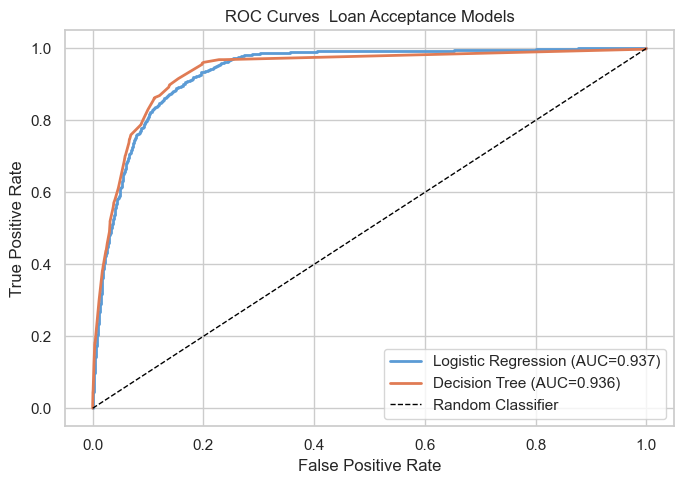

In [50]:
# ROC Curves
plt.figure(figsize=(7, 5))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#5B9BD5'),
    ('Decision Tree',       y_prob_dt, '#E07B54')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves  Loan Acceptance Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

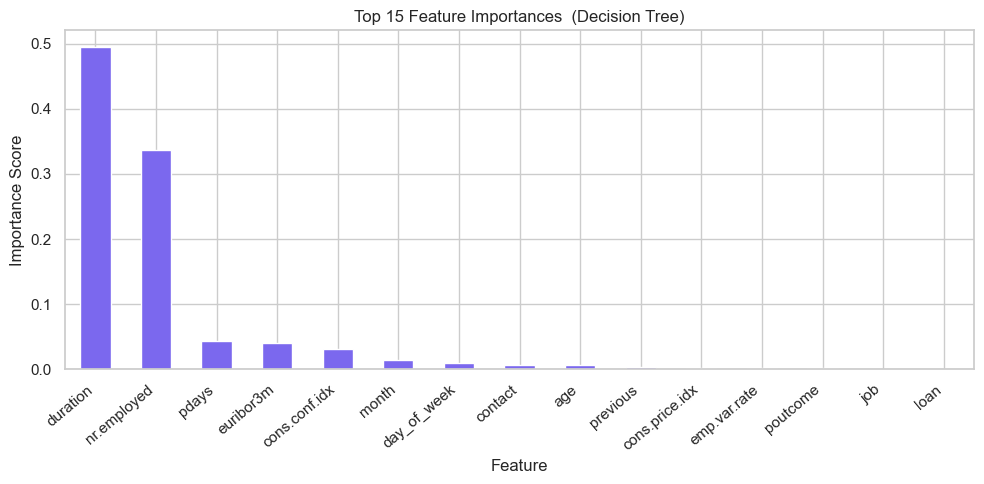

duration          0.4953
nr.employed       0.3366
pdays             0.0444
euribor3m         0.0409
cons.conf.idx     0.0309
month             0.0146
day_of_week       0.0104
contact           0.0070
age               0.0065
previous          0.0035
cons.price.idx    0.0029
emp.var.rate      0.0028
poutcome          0.0021
job               0.0013
loan              0.0009


In [51]:
# Feature importances  Decision Tree (top 15)
importances = pd.Series(
    dt.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='mediumslateblue', edgecolor='white')
plt.title('Top 15 Feature Importances  (Decision Tree)')
plt.xlabel('Feature'); plt.ylabel('Importance Score')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()
print(importances.round(4).to_string())

In [52]:
# 5-Fold Cross-Validation for model robustness
cv_lr = cross_val_score(LogisticRegression(max_iter=1000), X_scaled, y, cv=5, scoring='roc_auc')
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=6), X_scaled, y, cv=5, scoring='roc_auc')

print(f'Logistic Regression — 5-Fold CV AUC: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print(f'Decision Tree       — 5-Fold CV AUC: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')

Logistic Regression — 5-Fold CV AUC: 0.7316 ± 0.1285
Decision Tree       — 5-Fold CV AUC: 0.2623 ± 0.1642


## 7. Conclusion

### Key Insights:

1. **Severe class imbalance**  only ~11.3% of customers (4,640) accepted the offer. ROC-AUC is far more informative than accuracy for this task.
2. **`duration` (call length)** is the strongest predictor ; longer calls strongly correlate with acceptance. However, this feature is only known after the call, so it cannot be used for proactive targeting in real deployments.
3. **Economic indicators** (`euribor3m`, `nr.employed`, `emp.var.rate`, `cons.price.idx`) are among the top predictors ; customers are more receptive during periods of economic uncertainty.
4. **`poutcome`** (previous campaign outcome) is highly predictive ; customers who accepted offers in previous campaigns are far more likely to accept again.
5. **'unknown' values** were present in `job` (330), `education` (1,731), and `default` (8,597); these were treated as their own category then mode-imputed.
6. **Age** shows that students and retirees (younger and older age groups) tend to have higher acceptance rates.
7. Both models perform consistently across 5-fold cross-validation, confirming results are not due to a lucky train/test split.

### Customer Segments More Likely to Accept:
- Previously successful campaign contacts
- Customers contacted during economically uncertain periods (low euribor3m)
- Students and retirees by job category
- Longer call duration (as a quality signal during the call)

**Recommendation:** Prioritise re-targeting customers with successful prior interactions, and schedule campaigns during periods of low interest rates.